In [7]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; None if missing."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None, None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)
        # generic helper
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tStudyDescription":
                study = _first_text(node, "value")
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, "studyDescription")

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName("subjectInformation")
        if sub:
            pid = _first_text(sub[0], "patientID")

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info["includes"]:
            if token in s:
                return cat
    return None

data_dir  = "../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test"  # folder containing the .h5 files
# --------------------------------------

scan_categories = {
    "SPINE": {"includes": ["L-SPINE","LSPINE","L SPINE","C-SPINE","CSPINE","C SPINE","T-SPINE","T SPINE",
                          "AX T2 T-SP","AX T2 T-SP WARP"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS","ATH PUBALGIA"]},
    "HIP": {"includes": ["LT HIP","RT HIP"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA","RIBS","LT FEMUR"]},
    "LEG_TIBFIB": {"includes": ["LT LEG","RT TIB-FIB"]},
    "KNEE": {"includes": ["LT KNEE","RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER","RT SHOULDER"]},
    "ANKLE": {"includes": ["LT ANKLE","RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT","RT FOOT"]},
    "ELBOW": {"includes": ["LT ELBOW","RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST","RT WRIST","LT THUMB","RT THUMB","RT HAND","WRIST RT"]},
    
}

Loaded 4800 recon entries across 11 models + baseline.


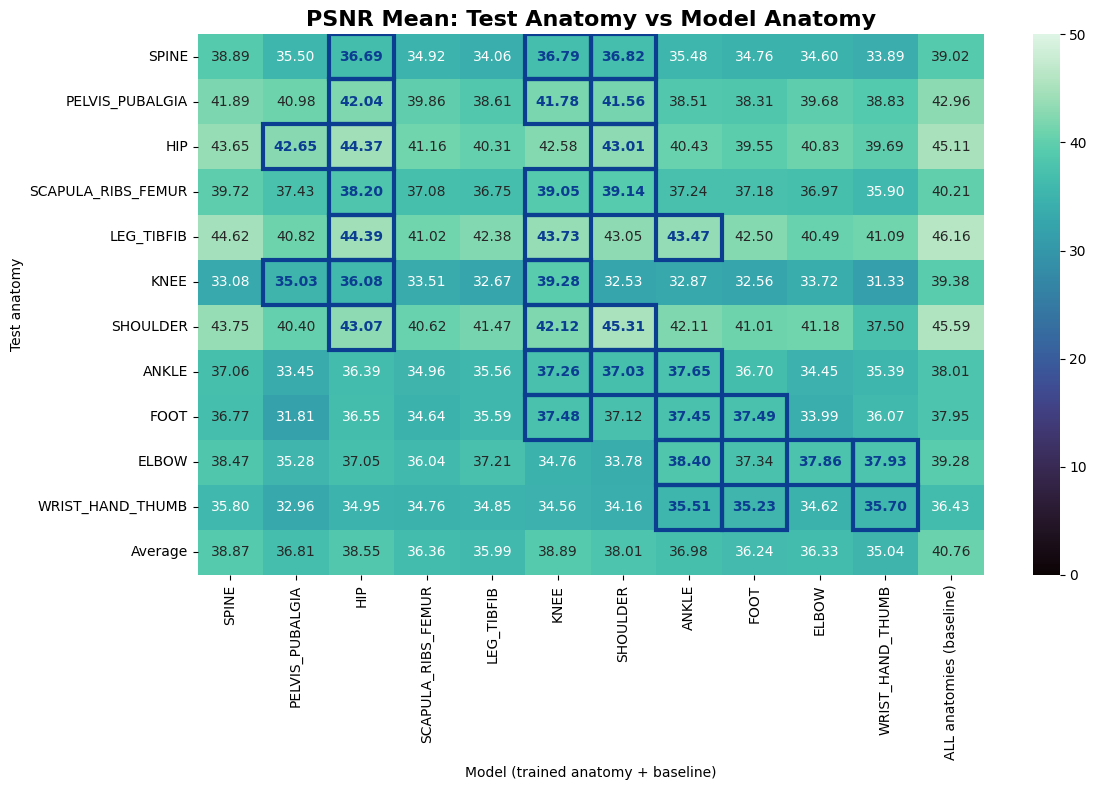

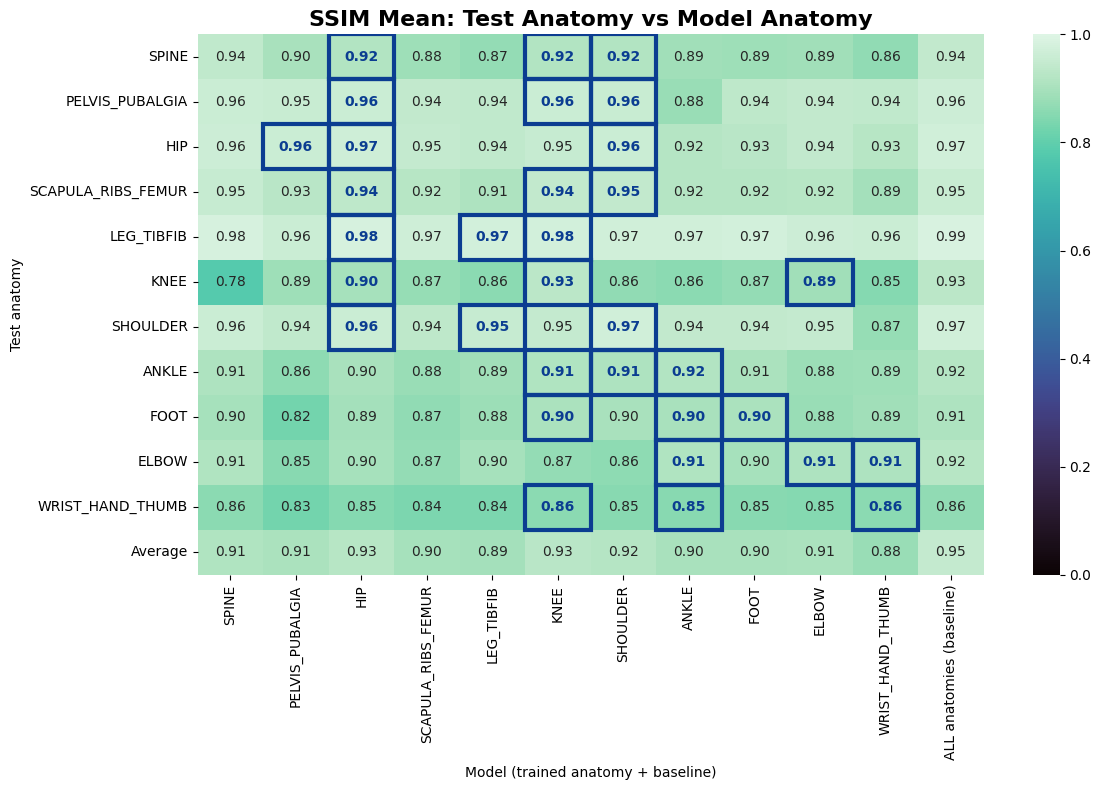


Diagonal PSNR margins (trained-on vs best other anatomy model, excluding baseline):
          category  PSNR_diag  PSNR_best_other  PSNR_margin
              KNEE  39.284149        36.084916     3.199232
             SPINE  38.890192        36.821899     2.068292
          SHOULDER  45.309006        43.748806     1.560200
               HIP  44.366730        43.645509     0.721220
             ANKLE  37.653966        37.258205     0.395761
              FOOT  37.488949        37.482333     0.006616
  WRIST_HAND_THUMB  35.697611        35.804598    -0.106986
             ELBOW  37.857544        38.471694    -0.614150
   PELVIS_PUBALGIA  40.981064        42.042476    -1.061412
        LEG_TIBFIB  42.379293        44.622282    -2.242988
SCAPULA_RIBS_FEMUR  37.084974        39.724275    -2.639301

Average row PSNR values (global metrics):
model_category
SPINE                       38.873317
PELVIS_PUBALGIA             36.811449
HIP                         38.551542
SCAPULA_RIBS_FEMUR     

In [10]:
# Cross-anatomy heatmaps: rows=test anatomy (from study headers), cols=model (from folder name)
import re, json, os, numpy as np, h5py
try:
    import seaborn as sns
    _HAS_SEABORN = True
except ImportError:
    _HAS_SEABORN = False

# List all model result directories (update if paths differ)
#/home/paula/msk_mri_dataset/varnet/outputs/january_exps/anatomies_full/test_on_msk
MODEL_RESULT_DIR = "../outputs/january_exps/anatomies_full/test_on_msk/varnet_msk_anatomy_"
ACCELERATIONS=8
CASCADES=8

baseline_dir = "../outputs/january_exps/test_on_msk/varnet_mskmrpro_FULL_casc8_acc8"
baseline_col_name = "ALL anatomies (baseline)"

# Helper to extract model anatomy keyword from path
_model_pat = re.compile(r"msk_anatomy_([^/]+?)_casc", re.IGNORECASE)

def infer_model_category(path):
    m = _model_pat.search(path)
    if not m:
        return os.path.basename(path)
    raw = m.group(1).upper()
    # Map raw form to canonical scan_categories key (simple fuzzy matches)
    for cat in scan_categories.keys():
        norm_cat = cat.replace('-', '_').replace(' ', '_').upper()
        if raw == norm_cat:
            return cat
    mapping = {
        'LEG_TIBFIB': 'LEG_TIBFIB',
        'WRIST_HAND_THUMB': 'WRIST_HAND_THUMB',
        'PELVIS_PUBALGIA': 'PELVIS_PUBALGIA',
        'SCAPULA_RIBS_FEMUR': 'SCAPULA_RIBS_FEMUR',
    }
    return mapping.get(raw, raw)

# Robust extractor for global means with fallbacks to per_volume means if needed
def _extract_stat(x):
    if x is None:
        return None
    if isinstance(x, dict):
        for k in ("mean", "Mean", "MEAN", "avg", "average", "value"):
            if k in x:
                try:
                    return float(x[k])
                except Exception:
                    return None
        return None
    try:
        return float(x)
    except Exception:
        return None

def extract_global_means(metrics_json, per_vol):
    psnr_mean = None
    ssim_mean = None
    if isinstance(metrics_json, dict):
        glob = metrics_json.get('global') or metrics_json.get('Global') or {}
        if isinstance(glob, dict):
            psnr_mean = _extract_stat(glob.get('PSNR'))
            ssim_mean = _extract_stat(glob.get('SSIM'))
        if psnr_mean is None:
            psnr_mean = _extract_stat(metrics_json.get('PSNR'))
        if ssim_mean is None:
            ssim_mean = _extract_stat(metrics_json.get('SSIM'))
    # Fallback: compute mean from per_volume entries
    if (psnr_mean is None or ssim_mean is None) and isinstance(per_vol, dict) and per_vol:
        ps = [v.get('PSNR') for v in per_vol.values() if v and v.get('PSNR') is not None]
        ss = [v.get('SSIM') for v in per_vol.values() if v and v.get('SSIM') is not None]
        if ps and psnr_mean is None:
            try:
                psnr_mean = float(np.nanmean(ps))
            except Exception:
                pass
        if ss and ssim_mean is None:
            try:
                ssim_mean = float(np.nanmean(ss))
            except Exception:
                pass
    return psnr_mean, ssim_mean

# Use same data_dir as earlier analysis for headers/category determination
header_data_dir = data_dir  # from earlier cell

all_rows = []
model_global_psnr = {}
model_global_ssim = {}
#for model_dir in model_result_dirs:
for cat in scan_categories.keys():
    model_dir = MODEL_RESULT_DIR+cat.lower()+f"_casc{CASCADES}_acc{ACCELERATIONS}"
    metrics_path = os.path.join(model_dir, 'metrics.json')
    model_cat = infer_model_category(model_dir)
    if not os.path.exists(metrics_path):
        print(f"Missing metrics.json in {model_dir}, skipping")
        continue
    try:
        with open(metrics_path, 'r') as f:
            mj = json.load(f)
        per_vol_local = mj.get('per_volume', {})
        # Use robust global extract for ALL categories
        psnr_g, ssim_g = extract_global_means(mj, per_vol_local)
        model_global_psnr[model_cat] = psnr_g
        model_global_ssim[model_cat] = ssim_g
    except Exception as e:
        print(f"Error reading {metrics_path}: {e}")
        continue

    for fname, m in per_vol_local.items():
        h5_path = os.path.join(header_data_dir, fname)
        
        study, _pid = parse_header_study_and_patient(h5_path)
        test_cat = categorize(study)
        all_rows.append({
            'file': fname,
            'test_category': test_cat,
            'model_category': model_cat,
            'PSNR': m.get('PSNR'),
            'SSIM': m.get('SSIM'),
        })

# Baseline metrics
baseline_metrics_path = os.path.join(baseline_dir, 'metrics.json')
baseline_per_vol = {}
baseline_global_psnr = None
baseline_global_ssim = None
if os.path.exists(baseline_metrics_path):
    try:
        with open(baseline_metrics_path, 'r') as f:
            b_mj = json.load(f)
        baseline_per_vol = b_mj.get('per_volume', {})
        # Use same robust extractor for baseline
        baseline_global_psnr, baseline_global_ssim = extract_global_means(b_mj, baseline_per_vol)
    except Exception as e:
        print(f"Error reading baseline metrics: {e}")
else:
    print("Baseline metrics.json not found; baseline column will be NaN.")

# Add baseline rows (model_category = baseline_col_name)
for fname, m in baseline_per_vol.items():
    h5_path = os.path.join(header_data_dir, fname)
    study, _pid = parse_header_study_and_patient(h5_path)
    test_cat = categorize(study)
    all_rows.append({
        'file': fname,
        'test_category': test_cat,
        'model_category': baseline_col_name,
        'PSNR': m.get('PSNR'),
        'SSIM': m.get('SSIM'),
    })
model_global_psnr[baseline_col_name] = baseline_global_psnr
model_global_ssim[baseline_col_name] = baseline_global_ssim

cross_df = pd.DataFrame(all_rows)
print(f"Loaded {len(cross_df)} recon entries across {len(model_result_dirs)} models + baseline.")

# Filter to only rows where test_category recognized
cross_df_clean = cross_df.dropna(subset=['test_category'])

# Ensure consistent ordering (one model per category) – append baseline last
ordered_categories = list(scan_categories.keys())
ordered_models = ordered_categories + [baseline_col_name]

# Aggregate means per test_category/model_category
psnr_matrix = cross_df_clean.groupby(['test_category','model_category'])['PSNR'].mean().reindex(index=ordered_categories, level=0).unstack('model_category').reindex(columns=ordered_models)
ssim_matrix = cross_df_clean.groupby(['test_category','model_category'])['SSIM'].mean().reindex(index=ordered_categories, level=0).unstack('model_category').reindex(columns=ordered_models)

# Append Average row using global metrics (PSNR/SSIM) from each model's metrics.json
avg_psnr_row = [model_global_psnr.get(m) for m in ordered_models]
avg_ssim_row = [model_global_ssim.get(m) for m in ordered_models]
psnr_matrix.loc['Average'] = avg_psnr_row
ssim_matrix.loc['Average'] = avg_ssim_row

# Plotting helper: highlight top-4 per row in dark blue, but IGNORE baseline + SPINE columns (no diagonal boxes)
def plot_heatmap(matrix, title, cmap='mako', vmin=None, vmax=None, fmt=".2f", topk=3, highlight_color='#0B3D91', ignore_cols=("SPINE",)):
    plt.figure(figsize=(12, 8))
    data = matrix.values
    nrows, ncols = data.shape
    row_labels = list(matrix.index)
    col_labels = list(matrix.columns)

    ignore_cols = set([c for c in ignore_cols if c in col_labels])
    # Always ignore baseline column from ranking/highlighting (like before)
    if baseline_col_name in col_labels:
        ignore_cols.add(baseline_col_name)
    ignore_idx = {col_labels.index(c) for c in ignore_cols}

    # Collect top-k col indices per row (skip NaNs); exclude ignored columns from ranking,
    # and exclude 'Average' row from ranking/highlighting.
    topk_per_row = []
    for i in range(nrows):
        if row_labels[i] == 'Average':
            topk_per_row.append([])
            continue
        row = data[i]
        candidate_idx = [j for j in range(ncols) if j not in ignore_idx and not np.isnan(row[j])]
        if not candidate_idx:
            topk_per_row.append([])
            continue
        # sort candidates by value desc
        sorted_idx = sorted(candidate_idx, key=lambda j: row[j], reverse=True)
        # If SPINE would have been in top-k, we effectively "go for top-k+1" by just excluding it above and taking topk.
        topk_per_row.append([int(j) for j in sorted_idx[:topk]])

    if _HAS_SEABORN:
        ax = sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=True)
    else:
        ax = plt.gca()
        im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)
        for i in range(nrows):
            for j in range(ncols):
                val = data[i, j]
                if not np.isnan(val):
                    ax.text(j+0.5, i+0.5, f"{val:{fmt}}", ha='center', va='center', color='white', fontsize=9)
        ax.set_xticks(np.arange(ncols)+0.5)
        ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(nrows)+0.5)
        ax.set_yticklabels(matrix.index)

    # Draw dark-blue rectangles around top-k cells per row (rows except 'Average')
    for i, js in enumerate(topk_per_row):
        for j in js:
            rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=highlight_color, linewidth=3)
            ax.add_patch(rect)

    # Make the top-k numbers dark-blue + bold in seaborn annotations
    if _HAS_SEABORN:
        texts = ax.texts
        for i, js in enumerate(topk_per_row):
            for j in js:
                idx = i * ncols + j
                if 0 <= idx < len(texts):
                    texts[idx].set_color(highlight_color)
                    texts[idx].set_weight('bold')

    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel('Model (trained anatomy + baseline)')
    plt.ylabel('Test anatomy')
    plt.tight_layout()
    plt.show()

# highlight top-3 non-(baseline, SPINE) per row
plot_heatmap(psnr_matrix, 'PSNR Mean: Test Anatomy vs Model Anatomy', cmap='mako', vmin=0, vmax=50, topk=3, ignore_cols=('SPINE',))
plot_heatmap(ssim_matrix, 'SSIM Mean: Test Anatomy vs Model Anatomy', cmap='mako', vmin=0, vmax=1, topk=3, ignore_cols=('SPINE',))

# Diagonal PSNR margins (exclude baseline column and Average row)
diag_advantages = []
for cat in scan_categories.keys():
    if cat in psnr_matrix.index and cat in psnr_matrix.columns:
        diag_val = psnr_matrix.loc[cat, cat]
        off_vals = psnr_matrix.loc[cat, [c for c in ordered_models if c != cat]].dropna()
        off_vals = off_vals.drop(labels=[baseline_col_name]) if baseline_col_name in off_vals.index else off_vals
        if not np.isnan(diag_val) and len(off_vals):
            best_off = off_vals.max()
            diag_advantages.append({'category': cat, 'PSNR_diag': diag_val, 'PSNR_best_other': best_off, 'PSNR_margin': diag_val - best_off})
adv_df = pd.DataFrame(diag_advantages).sort_values('PSNR_margin', ascending=False)
print('\nDiagonal PSNR margins (trained-on vs best other anatomy model, excluding baseline):')
print(adv_df.to_string(index=False))

print('\nAverage row PSNR values (global metrics):')
print(psnr_matrix.loc['Average'])


In [17]:
cross_df

,file,test_category,model_category,PSNR,SSIM
0,meas_MID00016_FID118817_COR_T2.h5,SPINE,SPINE,39.498194,0.957907
1,meas_MID00016_FID120712_COR_T2.h5,SPINE,SPINE,36.843238,0.952153
2,meas_MID00017_FID118818_SAG_T2.h5,SPINE,SPINE,39.476129,0.956627
3,meas_MID00018_FID118819_AXIAL_T2.h5,SPINE,SPINE,35.050789,0.849991
4,meas_MID00018_FID125144_COR_PD_FS.h5,KNEE,SPINE,35.192600,0.866064
...,...,...,...,...,...
3792,meas_MID00605_FID124541_SAG_T2_FS.h5,SHOULDER,SCAPULA_RIBS_FEMUR,38.551193,0.937531
3793,meas_MID00607_FID124543_COR_T2_FS.h5,SHOULDER,SCAPULA_RIBS_FEMUR,36.938771,0.912075
3794,meas_MID00608_FID124544_COR_T1.h5,SHOULDER,SCAPULA_RIBS_FEMUR,43.370648,0.949564
3795,meas_MID00615_FID124551_OBLIQUE_SAG_T1_CUFF.h5,SHOULDER,SCAPULA_RIBS_FEMUR,43.560343,0.898866


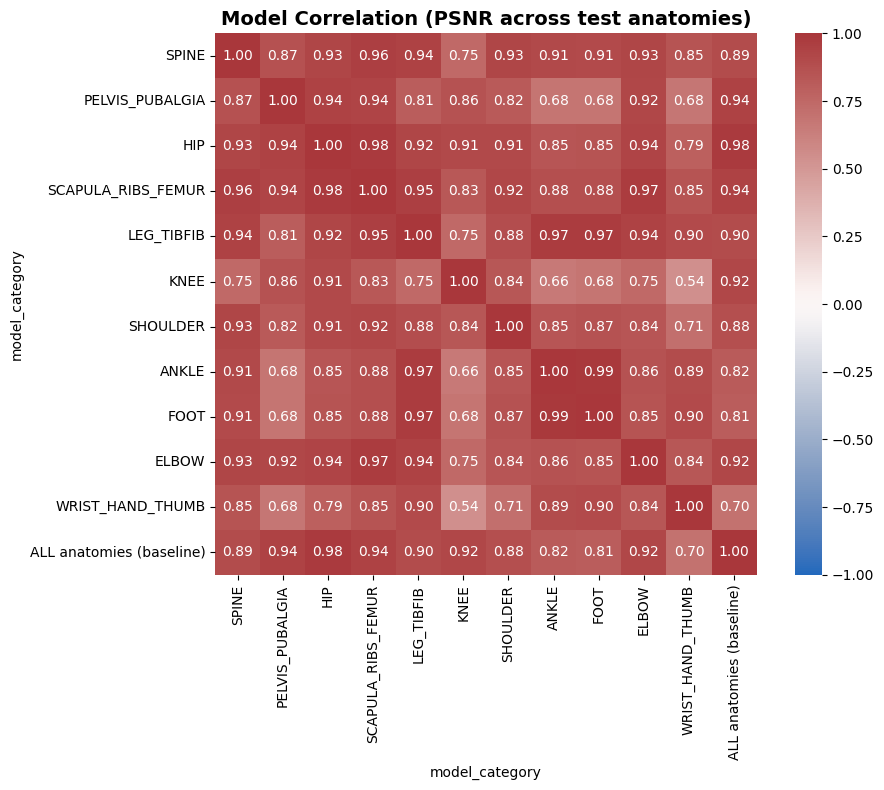

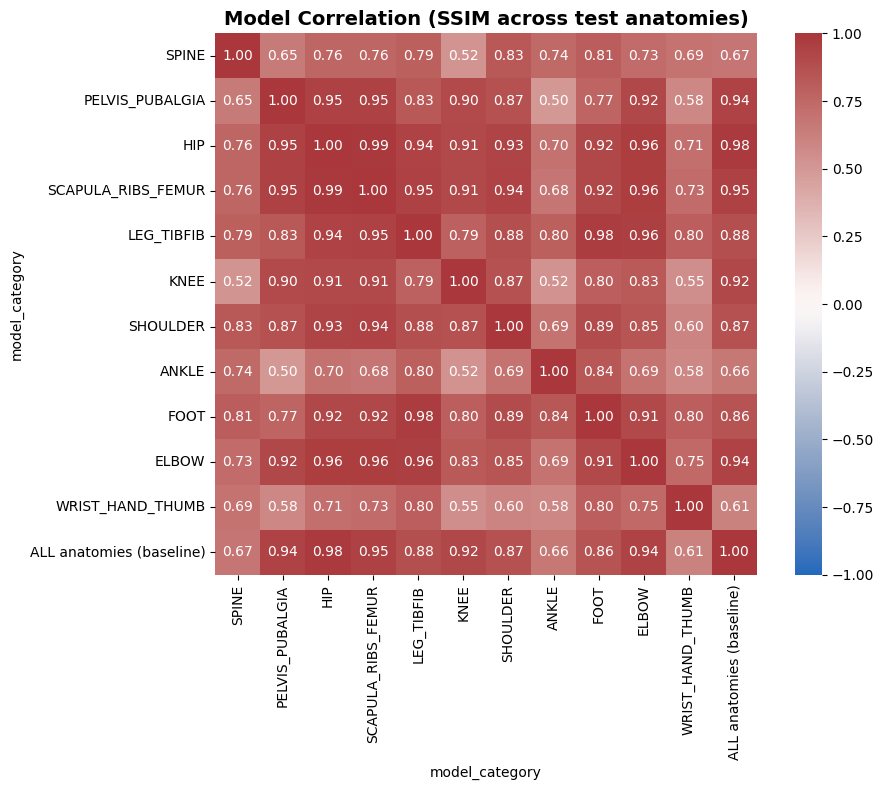

In [11]:
# Correlation of model performance across test anatomies
# Uses per-category mean PSNR/SSIM; drops the 'Average' row to avoid bias.
corr_psnr_base = psnr_matrix.drop(index=['Average'], errors='ignore')
corr_psnr_base = corr_psnr_base.dropna(axis=1, how='all')
psnr_corr = corr_psnr_base.corr(method='pearson', min_periods=2)

corr_ssim_base = ssim_matrix.drop(index=['Average'], errors='ignore')
corr_ssim_base = corr_ssim_base.dropna(axis=1, how='all')
ssim_corr = corr_ssim_base.corr(method='pearson', min_periods=2)

def plot_corr(corr, title, vmin=-1, vmax=1, cmap='vlag'):
    plt.figure(figsize=(10, 8))
    if _HAS_SEABORN:
        sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, vmin=vmin, vmax=vmax, square=True, cbar=True)
    else:
        ax = plt.gca()
        im = ax.imshow(corr.values, aspect='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(len(corr.columns)))
        ax.set_yticks(np.arange(len(corr.index)))
        ax.set_xticklabels(corr.columns, rotation=45, ha='right')
        ax.set_yticklabels(corr.index)
        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                val = corr.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=9)
    plt.title(title, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

plot_corr(psnr_corr, 'Model Correlation (PSNR across test anatomies)')
plot_corr(ssim_corr, 'Model Correlation (SSIM across test anatomies)')


,PSNR,SSIM
model_category,,
SPINE,33.449455,0.829715
PELVIS_PUBALGIA,31.812221,0.792218
HIP,33.958634,0.832217
SCAPULA_RIBS_FEMUR,30.522895,0.739638
LEG_TIBFIB,27.574326,0.724626
KNEE,23.549921,0.692742
SHOULDER,29.775365,0.779156
ANKLE,29.504915,0.773652
FOOT,27.709184,0.754718


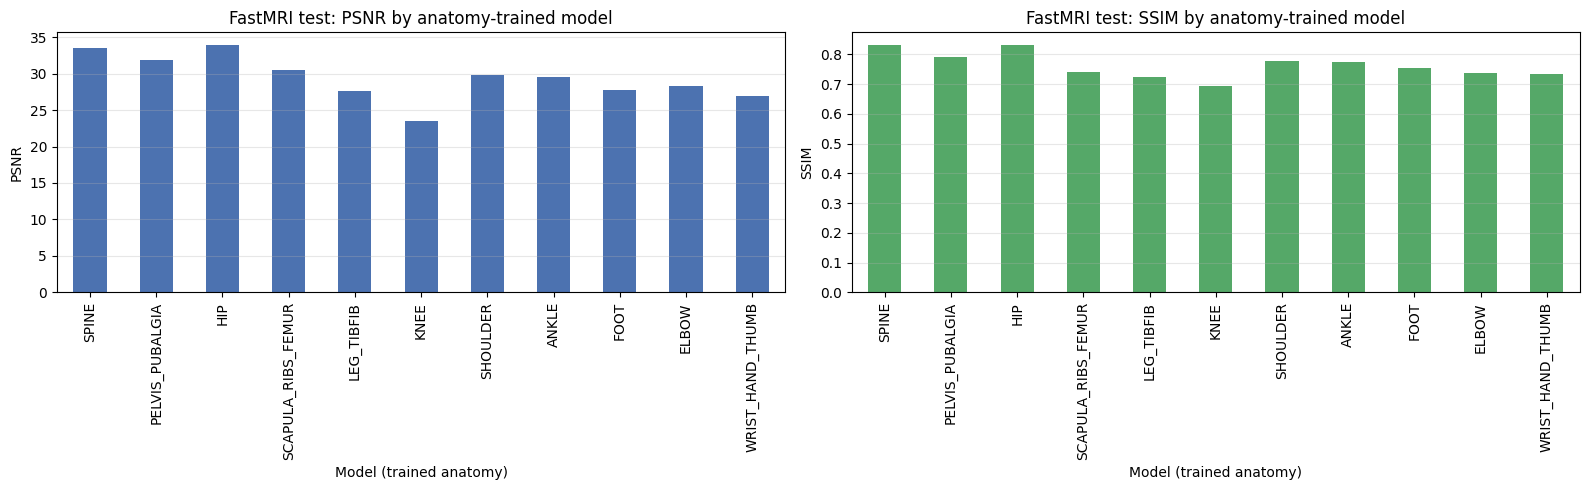

In [12]:
# Bar plot: anatomy-trained models evaluated on FastMRI (single test category)

# Assumption (based on existing paths): each anatomy model has a corresponding FastMRI test folder
# under ../outputs/january_exps/anatomies_full/test_on_fastmri/
# with name pattern: varnet_msk_anatomy_{cat}_casc{CASCADES}_acc{ACCELERATIONS}/metrics.json

FASTMRI_ROOT = "../outputs/january_exps/anatomies_full/test_on_fastmri"
FASTMRI_MODEL_PREFIX = "varnet_msk_anatomy_"

def _safe_load_json(path):
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except Exception:
        return None

fastmri_rows = []
for cat in scan_categories.keys():
    model_dir = os.path.join(
        FASTMRI_ROOT,
        f"{FASTMRI_MODEL_PREFIX}{cat.lower()}_casc{CASCADES}_acc{ACCELERATIONS}",
    )
    metrics_path = os.path.join(model_dir, "metrics.json")
    mj = _safe_load_json(metrics_path)
    if mj is None:
        print(f"Missing/invalid metrics.json for {cat}: {metrics_path}")
        fastmri_rows.append({"model_category": cat, "PSNR": np.nan, "SSIM": np.nan})
        continue
    per_vol = mj.get('per_volume', {}) if isinstance(mj, dict) else {}
    psnr_g, ssim_g = extract_global_means(mj, per_vol)
    fastmri_rows.append({"model_category": cat, "PSNR": psnr_g, "SSIM": ssim_g})

fastmri_df = pd.DataFrame(fastmri_rows)
fastmri_df = fastmri_df.set_index("model_category").reindex(list(scan_categories.keys()))
display(fastmri_df)

# Simple bar plots (one for PSNR, one for SSIM)
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

fastmri_df["PSNR"].plot(kind="bar", ax=axs[0], color="#4C72B0")
axs[0].set_title("FastMRI test: PSNR by anatomy-trained model")
axs[0].set_xlabel("Model (trained anatomy)")
axs[0].set_ylabel("PSNR")
axs[0].grid(axis='y', alpha=0.3)

fastmri_df["SSIM"].plot(kind="bar", ax=axs[1], color="#55A868")
axs[1].set_title("FastMRI test: SSIM by anatomy-trained model")
axs[1].set_xlabel("Model (trained anatomy)")
axs[1].set_ylabel("SSIM")
axs[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
